#Steel Industry Energy Consumption: Exploratory Data Analysis & Feature Engineering

**Dataset:** Steel Industry Energy Consumption (UCI ML Repository)
**Objective:** Deep EDA, feature engineering, and identification of data quality issues that could affect model training.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline


## 2. Load Dataset & Inspect Structure

In [3]:
df = pd.read_csv('/content/Steel_industry_data.csv')
print("=== SHAPE ===")
print(df.shape)
print("\n=== DTYPES ===")
print(df.dtypes)
print("\n=== HEAD ===")
print(df.head())
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== DESCRIBE ===")
print(df.describe())


=== SHAPE ===
(35040, 11)

=== DTYPES ===
date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
dtype: object

=== HEAD ===
               date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0  01/01/2018 00:15       3.17                                  2.95   
1  01/01/2018 00:30       4.00                                  4.46   
2  01/01/2018 00:45       3.24                                  3.28   
3  01/01/2018 01:00       3.31                                  3.56   
4  01/01/2018 01:15       3.82            

In [4]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


**Observations:** The dataset has 35,040 rows (15-minute interval readings across the year 2018) and 11 original columns, with **no missing values** and **no duplicate rows**. The `date` column is currently a string and needs to be parsed to datetime. `WeekStatus`, `Day_of_week`, and `Load_Type` are categorical (object) columns.

## 3. Date Feature Engineering
Convert `date` to datetime and extract `Hour`, `DayOfWeekNum`, `Month`, and `Is_Weekend`.

In [5]:
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')
df['Hour'] = df['date'].dt.hour
df['DayOfWeekNum'] = df['date'].dt.dayofweek
df['Month'] = df['date'].dt.month
df['Is_Weekend'] = df['DayOfWeekNum'].apply(lambda x: 1 if x >= 5 else 0)

print(df[['date','Hour','DayOfWeekNum','Month','Is_Weekend']].head())
print("\nDate range:", df['date'].min(), "to", df['date'].max())


                 date  Hour  DayOfWeekNum  Month  Is_Weekend
0 2018-01-01 00:15:00     0             0      1           0
1 2018-01-01 00:30:00     0             0      1           0
2 2018-01-01 00:45:00     0             0      1           0
3 2018-01-01 01:00:00     1             0      1           0
4 2018-01-01 01:15:00     1             0      1           0

Date range: 2018-01-01 00:00:00 to 2018-12-31 23:45:00


## 4. Feature: Power Factor Ratio
`Power_Factor_Ratio = Leading_Current_Power_Factor / Lagging_Current_Power_Factor`

In [6]:
df['Power_Factor_Ratio'] = df['Leading_Current_Power_Factor'] / df['Lagging_Current_Power_Factor']

n_bad_ratio = df['Power_Factor_Ratio'].isna().sum() + np.isinf(df['Power_Factor_Ratio']).sum()
print(f"Rows with undefined Power_Factor_Ratio (division by zero): {n_bad_ratio}")

# Fix division-by-zero issue: 1 row has Lagging_Current_Power_Factor == 0
df['Power_Factor_Ratio'] = df['Power_Factor_Ratio'].replace([np.inf, -np.inf], np.nan)
df['Power_Factor_Ratio'] = df['Power_Factor_Ratio'].fillna(df['Power_Factor_Ratio'].median())

df['Power_Factor_Ratio'].describe()


Rows with undefined Power_Factor_Ratio (division by zero): 1


,Power_Factor_Ratio
count,35040.000000
mean,1.173233
std,0.587457
min,0.125000
25%,1.001810
50%,1.136105
75%,1.579280
max,2.707093


## 5. Feature: High Usage Flag (Binary)
Mark rows where `Usage_kWh` is above the 75th percentile as `1`, else `0`.

In [7]:
p75 = df['Usage_kWh'].quantile(0.75)
df['High_Usage_Flag'] = (df['Usage_kWh'] > p75).astype(int)

print("75th percentile of Usage_kWh:", round(p75, 3))
print(df['High_Usage_Flag'].value_counts())


75th percentile of Usage_kWh: 51.238
High_Usage_Flag
0    26280
1     8760
Name: count, dtype: int64


## 6. Outlier Detection (IQR Method) on Usage_kWh

IQR bounds: lower=-68.856, upper=123.294
Number of outliers in Usage_kWh: 328 (0.94% of data)


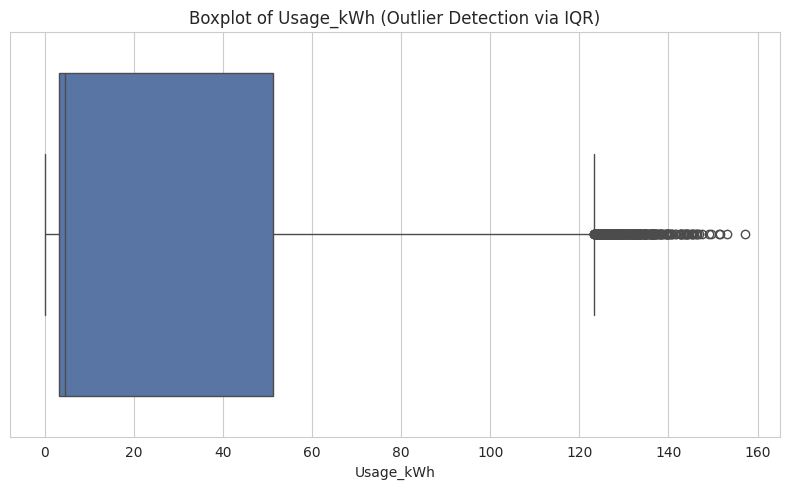

In [8]:
Q1 = df['Usage_kWh'].quantile(0.25)
Q3 = df['Usage_kWh'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Usage_kWh'] < lower) | (df['Usage_kWh'] > upper)]
print(f"IQR bounds: lower={lower:.3f}, upper={upper:.3f}")
print(f"Number of outliers in Usage_kWh: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of data)")

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Usage_kWh'], color='#4C72B0')
plt.title('Boxplot of Usage_kWh (Outlier Detection via IQR)')
plt.xlabel('Usage_kWh')
plt.tight_layout()
plt.show()


**Note:** Since `Usage_kWh` is right-skewed (steel plant runs at low load most of the time with periodic high-load spikes), the IQR flags 328 high-usage readings as statistical outliers. These are *not* data errors — they represent genuine `Maximum_Load` operating periods and should be kept in the modeling dataset.

## 7. Correlation Heatmap

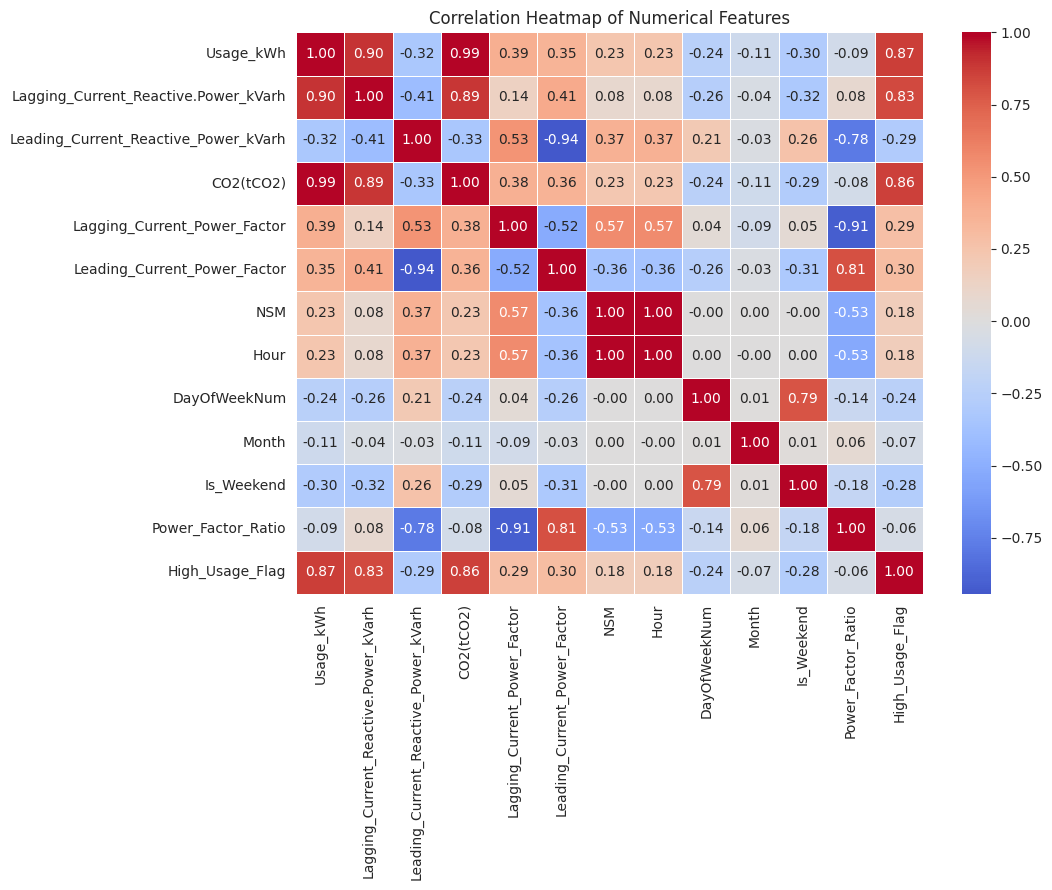

Top 3 features most correlated with Usage_kWh:
CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
High_Usage_Flag                         0.86784
Name: Usage_kWh, dtype: float64


In [9]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

top3 = corr['Usage_kWh'].drop('Usage_kWh').abs().sort_values(ascending=False).head(3)
print("Top 3 features most correlated with Usage_kWh:")
print(top3)


**Note:** `High_Usage_Flag` is trivially correlated with `Usage_kWh` because it is directly derived from it — this column must be dropped before modeling to avoid target leakage (handled in Part 2). Excluding it, the strongest real drivers of `Usage_kWh` are `CO2(tCO2)` and `Lagging_Current_Reactive.Power_kVarh`.

## 8. Average Energy Consumption by Load Type

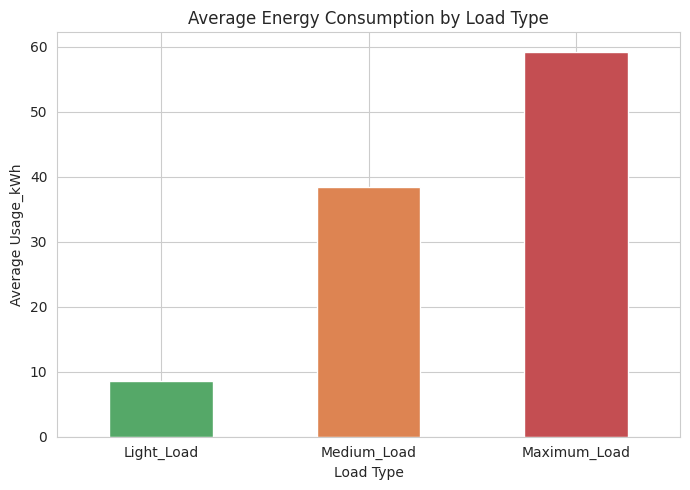

Load_Type
Light_Load       8.626207
Medium_Load     38.445394
Maximum_Load    59.265314
Name: Usage_kWh, dtype: float64


In [10]:
load_avg = df.groupby('Load_Type')['Usage_kWh'].mean().reindex(['Light_Load','Medium_Load','Maximum_Load'])

plt.figure(figsize=(7,5))
load_avg.plot(kind='bar', color=['#55A868','#DD8452','#C44E52'])
plt.title('Average Energy Consumption by Load Type')
plt.ylabel('Average Usage_kWh')
plt.xlabel('Load Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(load_avg)


## 9. Average Energy Usage by Hour of Day

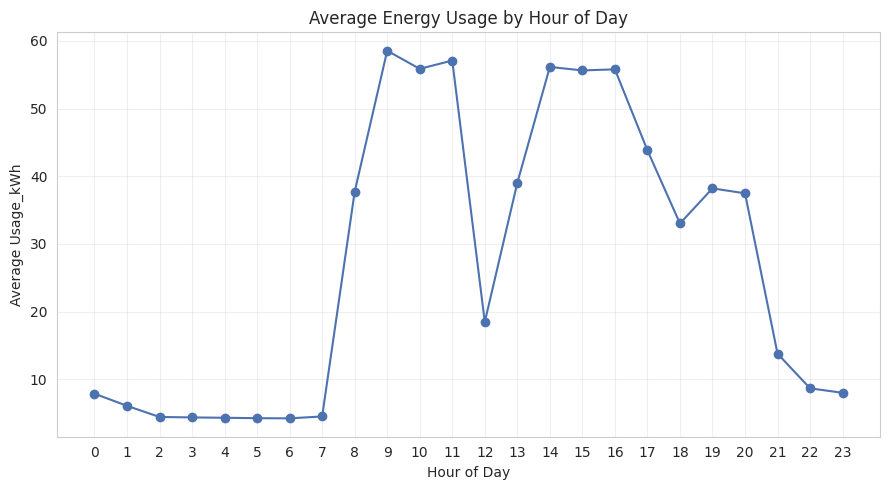

In [11]:
hourly_avg = df.groupby('Hour')['Usage_kWh'].mean()

plt.figure(figsize=(9,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='#4C72B0')
plt.title('Average Energy Usage by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Usage_kWh')
plt.xticks(range(0,24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Save Engineered Dataset
This engineered dataset is used as the input for Part 2 (`week2_baseline_models.ipynb`).

In [13]:
df.to_csv('/content/Steel_industry_data.csv', index=False)
print("Engineered dataset saved. Shape:", df.shape)
print("Columns:", list(df.columns))


Engineered dataset saved. Shape: (35040, 17)
Columns: ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeekNum', 'Month', 'Is_Weekend', 'Power_Factor_Ratio', 'High_Usage_Flag']


## 11. EDA Summary (250 words)

The dataset contains 35,040 fifteen-minute readings from a steel plant across all of 2018, with no missing values and no duplicate rows, indicating good raw data quality. The main data quality issue found was a single row with `Lagging_Current_Power_Factor = 0`, which produced an undefined (NaN) value when engineering `Power_Factor_Ratio`; this was resolved by imputing the median ratio. The IQR method flagged 328 readings (0.94%) as statistical outliers in `Usage_kWh`, but these correspond to genuine `Maximum_Load` operating periods rather than sensor errors, so they were retained.

The features most strongly correlated with `Usage_kWh` are `CO2(tCO2)` (r = 0.99), `Lagging_Current_Reactive.Power_kVarh` (r = 0.90), and the engineered `High_Usage_Flag` (r = 0.87, though this is trivially derived from the target and must be excluded from modeling). The near-perfect CO2 correlation makes sense physically: CO2 emissions scale directly with the plant's electrical energy consumption.

The most interesting pattern discovered is the clear operational rhythm of the plant: average usage is lowest during `Light_Load` periods (~8.6 kWh) and roughly 7x higher during `Maximum_Load` periods (~59.3 kWh), and the hourly usage curve shows a pronounced ramp-up starting around 7-8 AM that stays elevated through the working day before dropping off in the evening — consistent with a day-shift-driven production schedule.

**Hypothesis:** Energy spikes are primarily driven by production shift scheduling (weekday daytime hours with `Maximum_Load` operations) rather than random variation, meaning `Hour`, `Is_Weekend`, and `Load_Type` should be strong predictive features for a downstream regression model.